<a href="https://colab.research.google.com/github/Mahima-Bachhav/Reinforcement_Basics/blob/main/BasicNoob_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install x11-utils > /dev/null 2>&1
!pip install pyglet > /dev/null 2>&1
!apt-get install -y xvfb python-opengl > /dev/null 2>&1a

/bin/bash: line 1: 1a: ambiguous redirect


In [ ]:
!pip install gym pyvirtualdisplay > /dev/null 2>&1

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

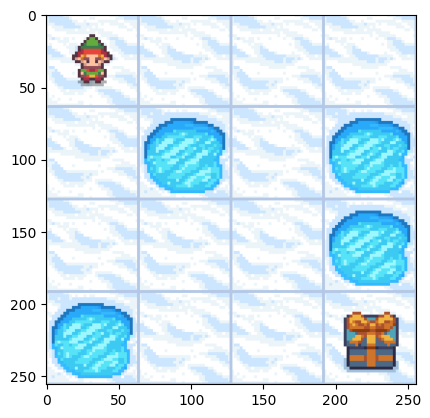

In [ ]:
env = gym.make(
    'FrozenLake-v1',
    desc=None,
    map_name="4x4",
    is_slippery=True,
    reward_schedule=(1, 0, 0),
    render_mode='rgb_array'
)
env.reset()
prev_screen = env.render()
plt.imshow(prev_screen)

In [ ]:
act = env.action_space.sample()

In [ ]:
act

np.int64(1)

In [ ]:
env.observation_space.n

np.int64(16)

In [ ]:
print(f"Num actions:{env.action_space.n}, Num states:{env.observation_space.n}")

Num actions:4, Num states:16


In [ ]:
import random
num_eps = 1000
env.reset()
total_reward = 0
for _ in range(num_eps):
  # action = env.action_space.sample() #random action
  action = random.randint(1,2) #greedy action: either move right or down
  obs,reward,terminated,truncated,info = env.step(action) #next state reached after the random action
  total_reward += reward #if reward == 1 goal reached else goal not reached
  if terminated or truncated: #one eps completed
    obs,info = env.reset()

env.close()

In [ ]:
total_reward

4

In [ ]:
success_rate = (total_reward/num_eps) * 100
avg_reward = (total_reward/num_eps)

In [ ]:
print(f"succes_rate:{success_rate}, avg_reward:{avg_reward}")

succes_rate:0.4, avg_reward:0.004


In [ ]:
import numpy as np
def create_Qtable(num_states, num_actions):
  shp = (num_states,num_actions)
  Qtable = np.zeros(shape=shp)
  return Qtable

In [ ]:
num_actions = env.action_space.n
num_states = env.observation_space.n

In [ ]:
Qtable = create_Qtable(num_states,num_actions)

In [ ]:
def greedy_action(Qtable,state):
  action = np.argmax(Qtable[state][:])
  return action

In [ ]:
def epsilon_greedy_policy(Qtable,state,epsilon):
  rnd_num = random.uniform(0,1)
  if rnd_num>epsilon:
    action = greedy_action(Qtable,state)
  else:
    action = env.action_space.sample()
  return action

In [ ]:
train_eps = 50000
lr = 0.7
eval_eps = 100
max_steps = 99
gamma = 0.95
eval_seed = []
max_epsilon = 1.0
min_epsilon = 0.05
decay_rate = 0.0005

In [ ]:
from tqdm import tqdm
def train(train_eps,lr,max_epsilon,min_epsilon,decay_rate,env,max_steps,Qtable):
  for i in tqdm(range(train_eps)):
    epsilon = min_epsilon + (max_epsilon-min_epsilon)*np.exp(-decay_rate*i)
    state,info = env.reset()
    step = 0
    terminated = False
    truncated = False

    for step in range(max_steps):
      action = epsilon_greedy_policy(Qtable,state,epsilon)
      new_state,reward,terminated,truncated,info = env.step(action)
      # next_action = greedy_action(Qtable,new_state)
      Qtable[state][action] = Qtable[state][action]+lr*(reward+gamma*np.max(Qtable[new_state][:])-Qtable[state][action])
      if terminated or truncated:
        break
      state = new_state

  return Qtable

In [ ]:
Qtable_after = train(train_eps,lr,max_epsilon,min_epsilon,decay_rate,env,max_steps,Qtable)

100%|██████████| 50000/50000 [00:34<00:00, 1454.24it/s]


In [ ]:
Qtable_after

array([[3.11144452e-01, 1.99360274e-01, 1.73403705e-01, 2.11326751e-01],
       [3.70939464e-03, 7.90968249e-03, 1.23010290e-01, 1.68219276e-01],
       [1.17827411e-01, 3.56319556e-02, 3.37209396e-02, 9.10009847e-02],
       [4.19963953e-02, 5.96097309e-02, 3.87518157e-02, 8.38221972e-02],
       [3.07163591e-01, 1.58653930e-01, 2.81728433e-02, 1.39884734e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.11129123e-01, 8.42030293e-04, 7.45661451e-04, 5.98963194e-05],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.49652026e-02, 7.34233538e-03, 1.16495627e-01, 3.00072793e-01],
       [2.73033985e-01, 4.60050861e-01, 1.14626539e-02, 1.56053282e-02],
       [2.03412830e-01, 2.05608675e-02, 2.81186323e-02, 8.94765267e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.55273313e-02, 2.49459635e-01, 3.54474509e

In [ ]:
def evaluate(env,max_steps,n_eval_episodes,Q,seed):
  episode_reward = []
  for i  in tqdm(range(n_eval_episodes)):
    if seed:
      state,info = env.reset(seed = seed[i])
    else:
      state,info = env.reset()
    step = 0
    truncated=False
    terminated = False
    total_rwd = 0
    for t in range(max_steps):
      action = greedy_action(Q,state)
      new_state,reward,terminated,truncated,info = env.step(action)
      total_rwd+=reward
      if terminated or truncated:
        break
      state = new_state
    # print(f"episode:{i} total_reward in this episode:{total_rwd}")
    episode_reward.append(total_rwd)
  mean_reward = np.mean(episode_reward)
  std_reward =  np.std(episode_reward)

  return mean_reward,std_reward

In [ ]:
mean_reward, std_reward = evaluate(env, max_steps, eval_eps, Qtable_after, eval_seed)

100%|██████████| 100/100 [00:00<00:00, 1852.53it/s]


In [ ]:
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

Mean_reward=0.74 +/- 0.44


In [ ]:
ARROWS = {
    0: "←",  # Left
    1: "↓",  # Down
    2: "→",  # Right
    3: "↑"   # Up
}

In [ ]:
def visualize_frozenlake_policy(env, Q):
    """
    Visualize FrozenLake grid with:
    - S = Start
    - F = Frozen
    - H = Hole
    - G = Goal
    - Arrows showing best action from Q-table
    """
    # Get the map layout
    desc = env.unwrapped.desc.astype(str)
    nrow, ncol = desc.shape

    # Best action from Q-table per state
    policy = np.argmax(Q, axis=1)

    # Create a plot
    fig, ax = plt.subplots(figsize=(ncol, nrow))
    ax.set_xticks(np.arange(ncol))
    ax.set_yticks(np.arange(nrow))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True)

    for r in range(nrow):
        for c in range(ncol):
            tile = desc[r, c]
            state = r * ncol + c

            # Background color for tiles
            if tile == "S":
                ax.text(c, r, "S", ha="center", va="center", fontsize=18, fontweight="bold")
            elif tile == "G":
                ax.text(c, r, "G", ha="center", va="center", fontsize=18, fontweight="bold")
            elif tile == "H":
                ax.text(c, r, "H", ha="center", va="center", fontsize=18, fontweight="bold")
            else:
                # For frozen tile F, show policy arrow
                ax.text(c, r, ARROWS[policy[state]], ha="center", va="center", fontsize=18)

    ax.set_title("FrozenLake Policy Visualization (from Q-table)")
    plt.gca().invert_yaxis()
    plt.show()

In [ ]:
def visualize_q_values(Q, state_shape):
    """
    Heatmap showing max Q-value per state (how confident the agent is).
    """
    max_q = np.max(Q, axis=1).reshape(state_shape)

    plt.figure(figsize=(state_shape[1], state_shape[0]))
    plt.imshow(max_q, cmap="viridis")
    plt.colorbar(label="Max Q-value")
    plt.title("State Value Heatmap (max Q per state)")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

ARROWS = {
    0: "←",  # Left
    1: "↓",  # Down
    2: "→",  # Right
    3: "↑"   # Up
}

COLORS = {
    "S": "#A8DADC",  # start (light blue)
    "F": "#F1FAEE",  # frozen (light)
    "H": "#E63946",  # hole (red)
    "G": "#2A9D8F",  # goal (green)
    "A": "#FFD166"   # agent (yellow)
}

def draw_grid(desc, agent_state=None, title="FrozenLake"):
    """
    Draw FrozenLake grid with colors and symbols.
    agent_state: integer state where agent is currently located
    """
    grid = desc.astype(str).copy()
    nrow, ncol = grid.shape

    if agent_state is not None:
        r, c = divmod(agent_state, ncol)
        # Mark agent without destroying tile info (we'll draw agent separately)
        agent_pos = (r, c)
    else:
        agent_pos = None

    fig, ax = plt.subplots(figsize=(ncol, nrow))
    ax.set_xlim(0, ncol)
    ax.set_ylim(0, nrow)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14)

    # Draw cells
    for r in range(nrow):
        for c in range(ncol):
            tile = grid[r, c]
            color = COLORS.get(tile, "white")

            # Rectangle cell
            rect = patches.Rectangle((c, nrow - 1 - r), 1, 1,
                                     linewidth=1, edgecolor="black", facecolor=color)
            ax.add_patch(rect)

            # Tile label
            ax.text(c + 0.5, nrow - 1 - r + 0.5, tile,
                    ha="center", va="center", fontsize=16, fontweight="bold")

    # Draw agent overlay
    if agent_pos is not None:
        r, c = agent_pos
        rect = patches.Rectangle((c, nrow - 1 - r), 1, 1,
                                 linewidth=2, edgecolor="black", facecolor=COLORS["A"], alpha=0.85)
        ax.add_patch(rect)
        ax.text(c + 0.5, nrow - 1 - r + 0.5, "A",
                ha="center", va="center", fontsize=18, fontweight="bold")

    plt.show()


def render_episode_stepwise(env, Q, sleep_time=0.7, max_steps=100):
    """
    Run 1 episode using greedy policy from Q-table and visualize each step.
    """
    desc = env.unwrapped.desc
    nrow, ncol = desc.shape

    state, _ = env.reset()
    done = False
    step = 0
    total_reward = 0

    while not done and step < max_steps:
        action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        draw_grid(desc, agent_state=state,
                  title=f"Step {step} | Action: {ARROWS[action]} | Reward: {reward}")

        print(f"Step {step}: State={state} -> Action={ARROWS[action]} -> Next State={next_state}, Reward={reward}")

        state = next_state
        step += 1
        time.sleep(sleep_time)

    # Final state shown
    draw_grid(desc, agent_state=state,
              title=f"Final State | Total Reward: {total_reward}")

    print("\n✅ Episode finished!")
    print("Total steps:", step)
    print("Total reward:", total_reward)

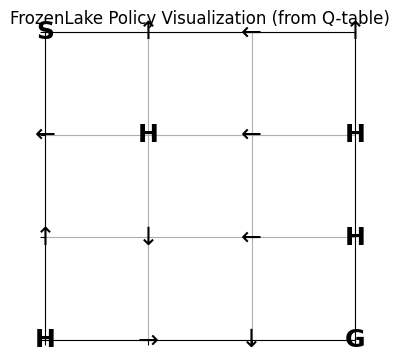

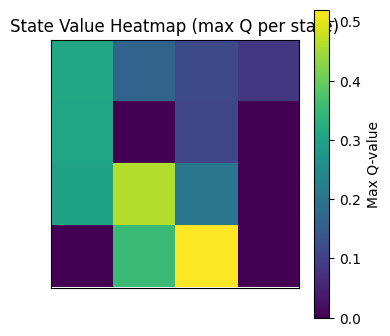

In [ ]:
visualize_frozenlake_policy(env, Qtable_after)
visualize_q_values(Qtable_after, env.unwrapped.desc.shape)


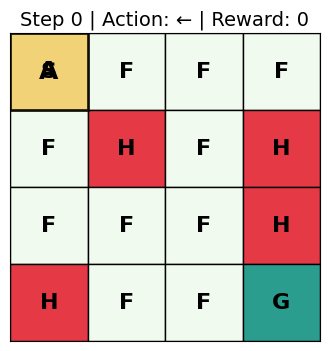

Step 0: State=0 -> Action=← -> Next State=0, Reward=0


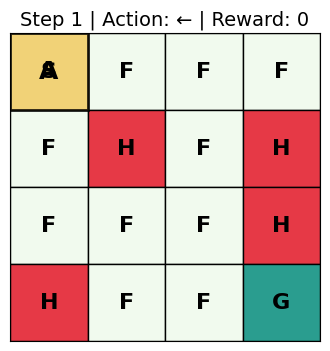

Step 1: State=0 -> Action=← -> Next State=0, Reward=0


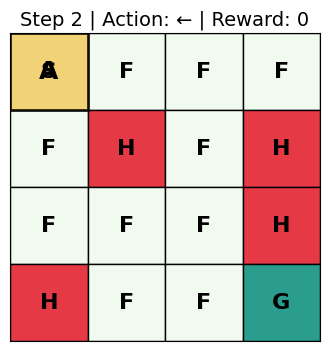

Step 2: State=0 -> Action=← -> Next State=0, Reward=0


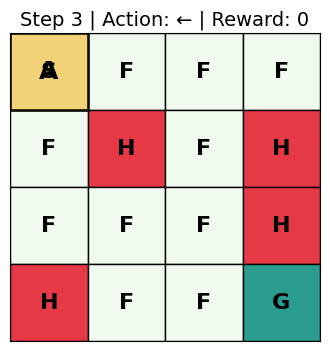

Step 3: State=0 -> Action=← -> Next State=4, Reward=0


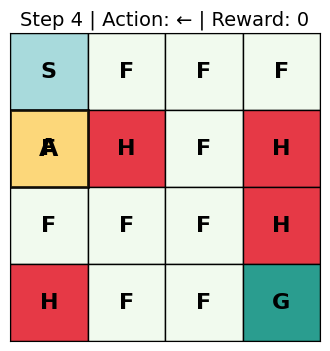

Step 4: State=4 -> Action=← -> Next State=0, Reward=0


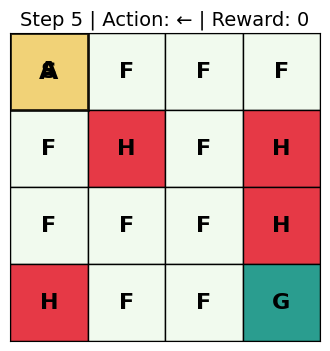

Step 5: State=0 -> Action=← -> Next State=0, Reward=0


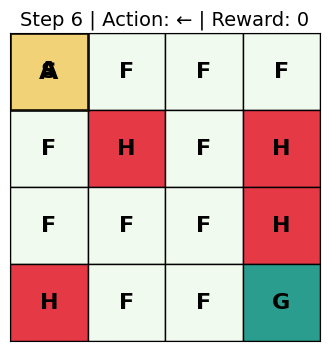

Step 6: State=0 -> Action=← -> Next State=0, Reward=0


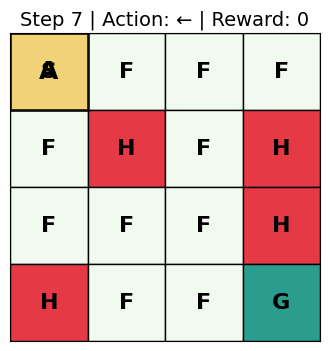

Step 7: State=0 -> Action=← -> Next State=0, Reward=0


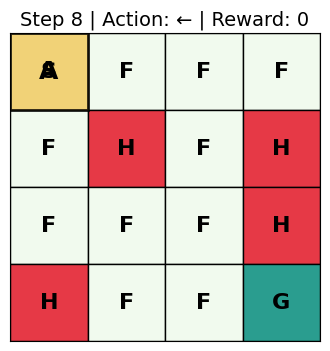

Step 8: State=0 -> Action=← -> Next State=0, Reward=0


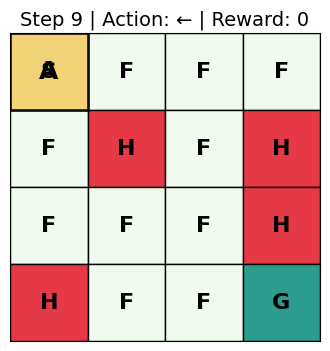

Step 9: State=0 -> Action=← -> Next State=0, Reward=0


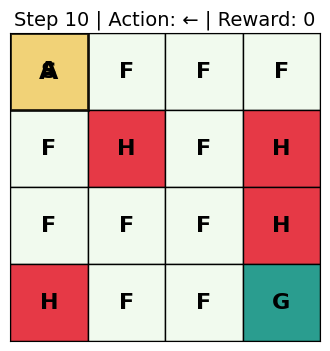

Step 10: State=0 -> Action=← -> Next State=4, Reward=0


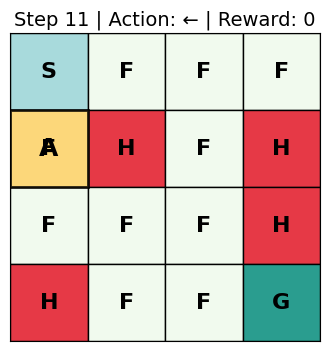

Step 11: State=4 -> Action=← -> Next State=4, Reward=0


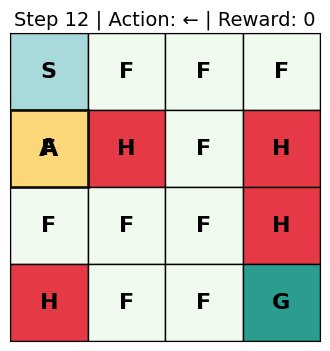

Step 12: State=4 -> Action=← -> Next State=4, Reward=0


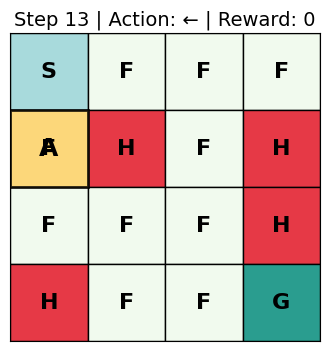

Step 13: State=4 -> Action=← -> Next State=8, Reward=0


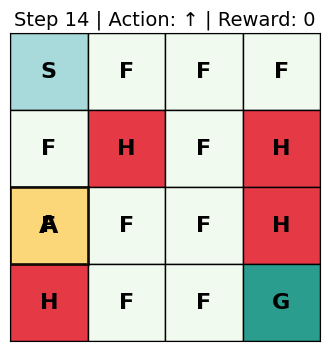

Step 14: State=8 -> Action=↑ -> Next State=8, Reward=0


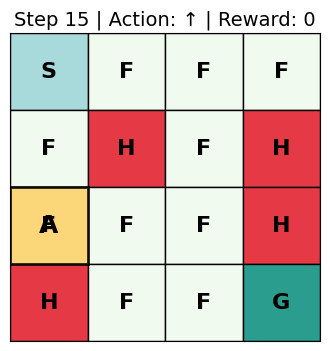

Step 15: State=8 -> Action=↑ -> Next State=8, Reward=0


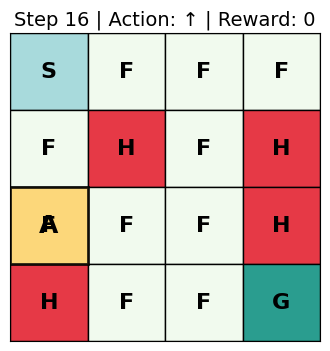

Step 16: State=8 -> Action=↑ -> Next State=4, Reward=0


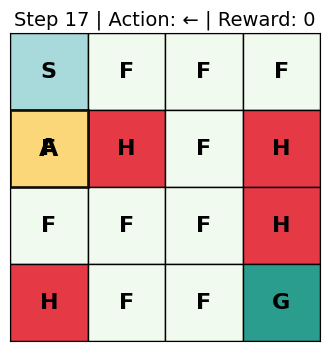

Step 17: State=4 -> Action=← -> Next State=4, Reward=0


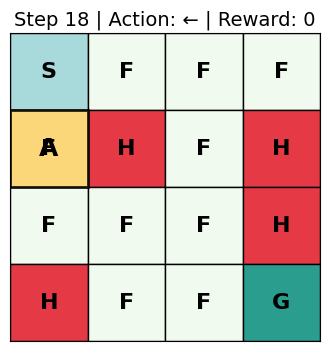

Step 18: State=4 -> Action=← -> Next State=4, Reward=0


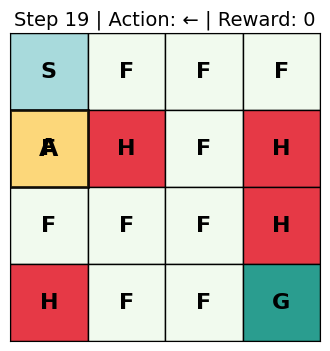

Step 19: State=4 -> Action=← -> Next State=4, Reward=0


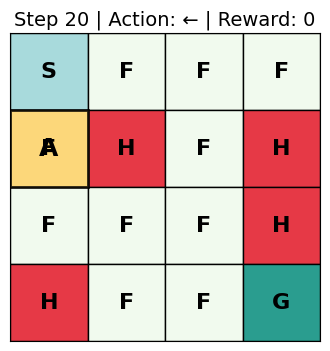

Step 20: State=4 -> Action=← -> Next State=8, Reward=0


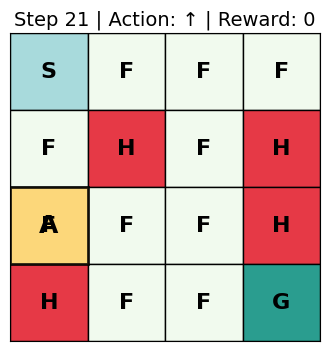

Step 21: State=8 -> Action=↑ -> Next State=9, Reward=0


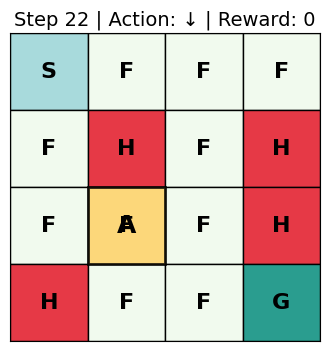

Step 22: State=9 -> Action=↓ -> Next State=8, Reward=0


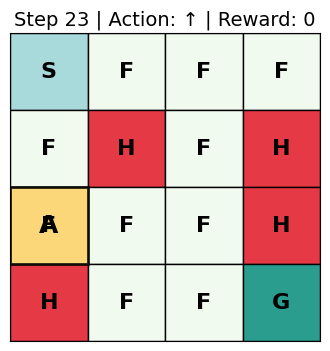

Step 23: State=8 -> Action=↑ -> Next State=8, Reward=0


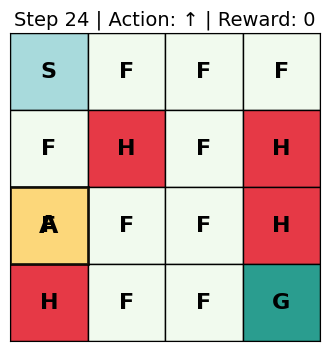

Step 24: State=8 -> Action=↑ -> Next State=8, Reward=0


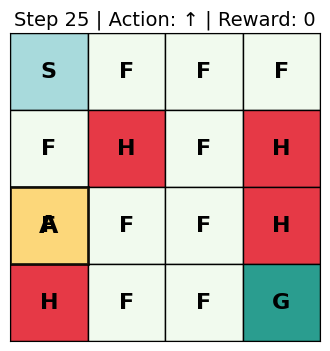

Step 25: State=8 -> Action=↑ -> Next State=8, Reward=0


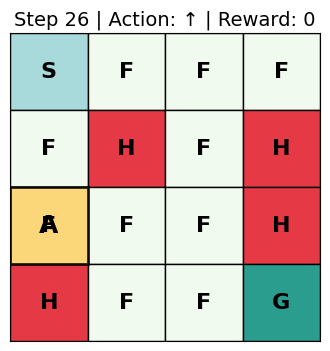

Step 26: State=8 -> Action=↑ -> Next State=9, Reward=0


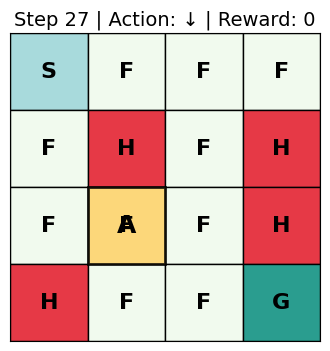

Step 27: State=9 -> Action=↓ -> Next State=10, Reward=0


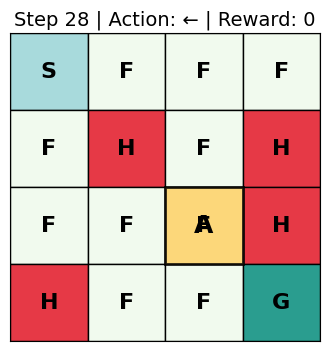

Step 28: State=10 -> Action=← -> Next State=14, Reward=0


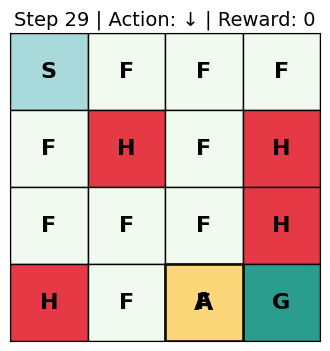

Step 29: State=14 -> Action=↓ -> Next State=13, Reward=0


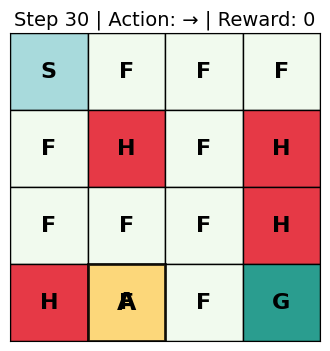

Step 30: State=13 -> Action=→ -> Next State=9, Reward=0


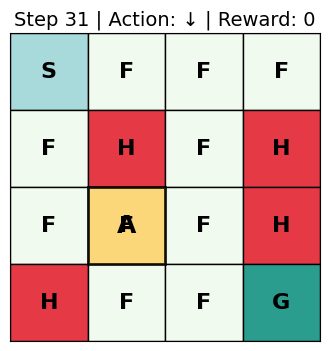

Step 31: State=9 -> Action=↓ -> Next State=13, Reward=0


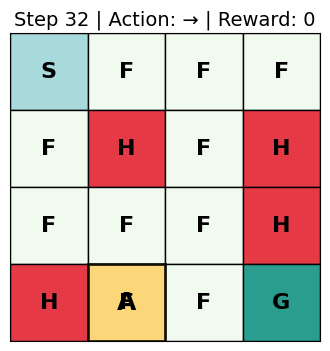

Step 32: State=13 -> Action=→ -> Next State=9, Reward=0


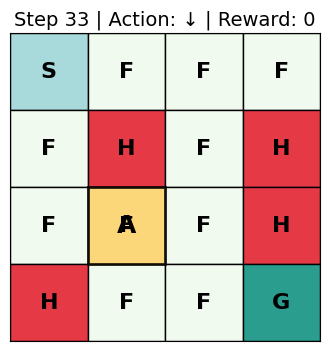

Step 33: State=9 -> Action=↓ -> Next State=13, Reward=0


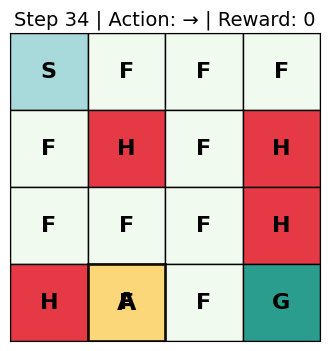

Step 34: State=13 -> Action=→ -> Next State=14, Reward=0


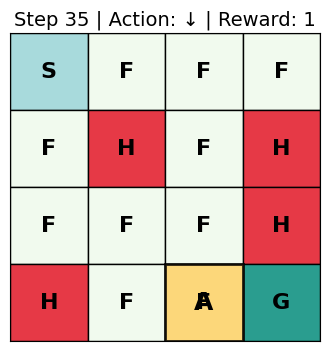

Step 35: State=14 -> Action=↓ -> Next State=15, Reward=1


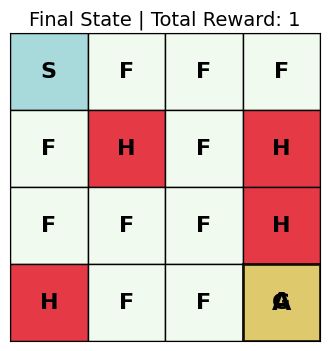


✅ Episode finished!
Total steps: 36
Total reward: 1


In [ ]:
render_episode_stepwise(env, Qtable_after, sleep_time=0.6)